# PMT 850 V, 20 MHz bandwidth, LED1 03/06/2026

This notebook uses the reusable `pmt_analysis.py` helpers for the full PMT LED workflow:

1. read the Keysight segmented HDF5 files,
2. subtract the baseline,
3. check the baseline removal,
4. compute pulse charge in `mV ns`,
5. fit the SPE charge spectrum.

The charge convention is `charge_mV_ns = - integral(V_baseline_subtracted dt)`, so negative-going PMT pulses have positive charge.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from pmt_analysis import (
    compute_charges,
    collect_peak_time_voltage_selection,
    compute_charges_for_windows,
    fit_spe_spectrum,
    print_spe_fit_result,
    read_keysight_h5_direct,
    spe_poisson_components,
    spe_poisson_model,
    standard_units,
    subtract_baseline,
    summarize_waveforms,
)

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# Read Data

In [2]:
data_dir = Path("data/calibLED/260603")
led1_files = sorted(data_dir.glob("baseline850V_BW20MHz_led1-*.h5"))

for file in led1_files:
    print(file)
print(f"Number of files: {len(led1_files)}")

data/calibLED/260603/baseline850V_BW20MHz_led1-1.h5
data/calibLED/260603/baseline850V_BW20MHz_led1-2.h5
data/calibLED/260603/baseline850V_BW20MHz_led1-3.h5
data/calibLED/260603/baseline850V_BW20MHz_led1-4.h5
Number of files: 4


In [3]:
maxEvts = 10000 # small sample size
time_s, voltage_sample_V, metadata = read_keysight_h5_direct(
    led1_files[0],
    segment_numbers=range(maxEvts),
)
time_ns, voltage_sample_mV, adc_step_mV, units_time, units_voltage = standard_units(
    time_s,
    voltage_sample_V,
    metadata,
)

print(f"Sample waveforms: {voltage_sample_mV.shape}")
print(f"Time range: {time_ns[0]:.3f} to {time_ns[-1]:.3f} ns")
print(f"Sampling step: {np.median(np.diff(time_ns)):.5f} ns")
print(f"ADC step: {adc_step_mV:.6f} mV")

Sample waveforms: (9999, 7993)
Time range: 13.744 to 76.181 ns
Sampling step: 0.00781 ns
ADC step: 0.001276 mV


# Set Config. Values

In [33]:
## config
baseline_window_ns = (14.0, 27.0)
integration_window_ns = (30.0, 70.0)
threshold_mV = -1. # threshold to compute mean waveform (if no cut, the baseline dominates)

peak_search_window_ns = integration_window_ns
allowed_peak_window_ns = (32.0, 40.0)
# min_peak_amplitude_mV = 1.0
global_peak_voltage_max_mV = None
out_of_window_peak_voltage_max_mV = -1.0
rise_low_fraction = 0.1
rise_high_fraction = 0.9
show_residual_errorbars = True

# Baseline Subtaction

In [34]:
voltage_sample_bs_mV, sample_baseline_mV = subtract_baseline(
    time_ns,
    voltage_sample_mV,
    baseline_window_ns=baseline_window_ns,
)

In [35]:
summary = summarize_waveforms(
    led1_files,
    baseline_window_ns=baseline_window_ns,
    chunk_size=4096,
    selection_mask=None
)

print(f'{summary.keys()} \n')

mean_waveform = summary["mean_waveform_mV"]
idx_min = int(np.argmin(mean_waveform))

print(f"Processed events: {summary['n_events']}")
print(f"Baseline window: {baseline_window_ns[0]:.1f}-{baseline_window_ns[1]:.1f} ns")
print(f"Baseline mean/std: {np.mean(summary['baseline_mV']):.4f} +/- {np.std(summary['baseline_mV']):.4f} mV")
print(f"Residual in baseline window: {np.mean(summary['baseline_check_mV']):.3e} +/- {np.std(summary['baseline_check_mV']):.3e} mV")
print(f"Mean waveform minimum: {summary['time_ns'][idx_min]:.3f} ns, {mean_waveform[idx_min]:.4f} mV")

dict_keys(['n_events', 'time_ns', 'mean_waveform_mV', 'std_waveform_mV', 'baseline_mV', 'baseline_check_mV', 'pulse_min_time_ns', 'pulse_amplitude_mV']) 

Processed events: 126728
Baseline window: 14.0-27.0 ns
Baseline mean/std: -0.3107 +/- 0.0711 mV
Residual in baseline window: -3.276e-08 +/- 3.097e-07 mV
Mean waveform minimum: 36.573 ns, -0.2540 mV


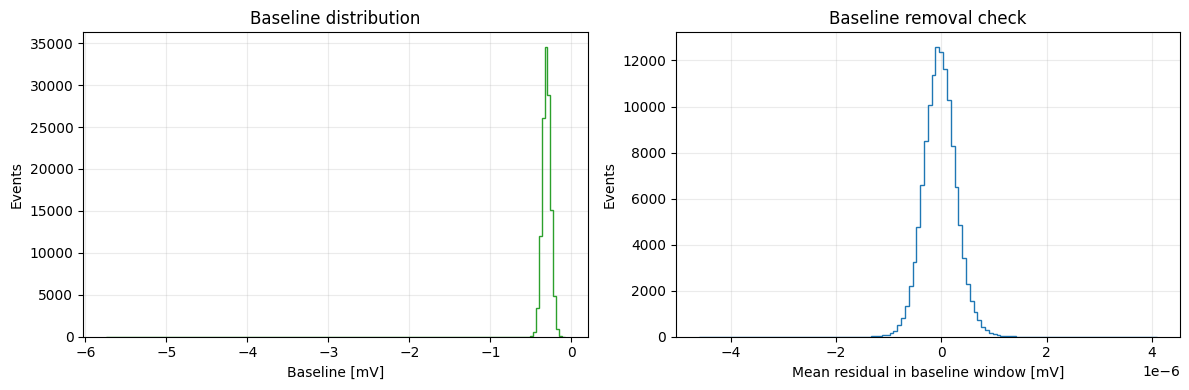

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(summary["baseline_mV"], bins=160, histtype="step", color="tab:green")
axes[0].set_xlabel("Baseline [mV]")
axes[0].set_ylabel("Events")
axes[0].set_title("Baseline distribution")
# axes[0].set_yscale('log')

axes[1].hist(summary["baseline_check_mV"], bins=120, histtype="step", color="tab:blue")
axes[1].set_xlabel("Mean residual in baseline window [mV]")
axes[1].set_ylabel("Events")
axes[1].set_title("Baseline removal check")
fig.tight_layout()

## Look at a small data sample

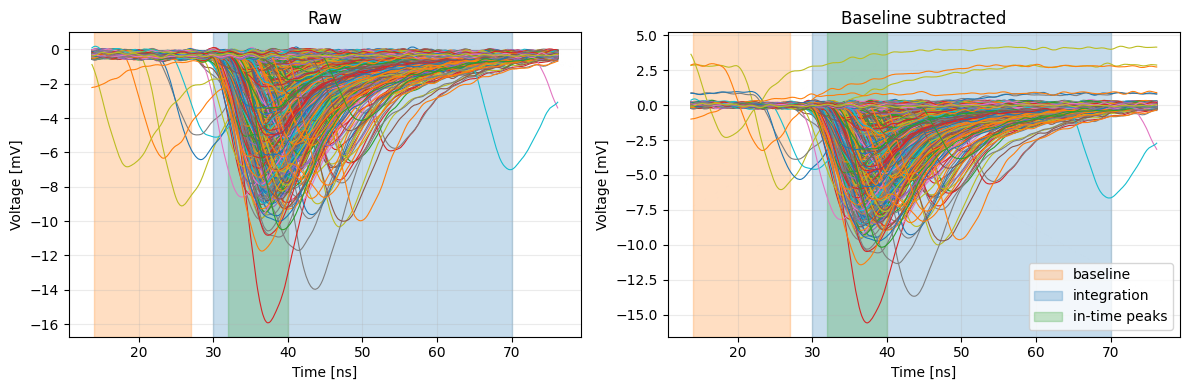

In [37]:
show_wfs = True

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for waveform in voltage_sample_mV[:maxEvts]:
    if show_wfs:
        axes[0].plot(time_ns, waveform, lw=0.8)
    else:
        axes[0].plot(time_ns, waveform, color="0.45", alpha=0.12, lw=0.8)
for waveform in voltage_sample_bs_mV[:maxEvts]:
    if show_wfs:
        axes[1].plot(time_ns, waveform, lw=0.8)
    else:
        axes[1].plot(time_ns, waveform, color="tab:blue", alpha=0.12, lw=0.8)

for ax in axes:
    ax.axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
    ax.axvspan(*integration_window_ns, color="tab:blue", alpha=0.25, label="integration")
    ax.axvspan(*allowed_peak_window_ns, color="tab:green", alpha=0.25, label="in-time peaks")
    ax.set_xlabel("Time [ns]")
    ax.set_ylabel("Voltage [mV]")
axes[0].set_title("Raw")
axes[1].set_title("Baseline subtracted")
axes[1].legend(loc="lower right")
fig.tight_layout()

# Selection

- remove peaks that are clearely out of time (+ small defie a threshold for a peak to be a paeak)

In [38]:
selection = collect_peak_time_voltage_selection(
    led1_files,
    baseline_window_ns=baseline_window_ns,
    peak_window_ns=allowed_peak_window_ns,
    global_peak_voltage_max_mV=global_peak_voltage_max_mV, # cut all events with higher below a cut (i.e. remove small waveforms)
    out_of_window_peak_voltage_max_mV=out_of_window_peak_voltage_max_mV,
    peak_search_window_ns=peak_search_window_ns,
    selection_mask=None,
    chunk_size=4096,
    low_fraction=rise_low_fraction,
    high_fraction=rise_high_fraction,
)
selection.keys()

dict_keys(['keep_mask', 'n_total', 'n_kept', 'efficiency', 'real_peak_mask', 'in_peak_window_mask', 'peak_time_ns', 'peak_value_mV', 'peak_amplitude_mV', 't_low_ns', 't_high_ns', 'rise_time_ns', 'rise_time_valid', 'low_fraction', 'high_fraction'])

## Display some stats. (small sample)

In [39]:
sample_n = len(voltage_sample_bs_mV)
sample_timing = {
    key: selection[key][:sample_n]
    for key in [
        "peak_time_ns",
        "peak_value_mV",
        "peak_amplitude_mV",
        "t_low_ns",
        "t_high_ns",
        "rise_time_ns",
        "rise_time_valid",
        "real_peak_mask",
        "in_peak_window_mask",
        "keep_mask",
    ]
}

sample_selection_mask = sample_timing["keep_mask"]
sample_real_peak_mask = sample_timing["real_peak_mask"] # Return events whose peak voltage passes a real-pulse threshold.
selected_sample_wfs = voltage_sample_bs_mV[sample_selection_mask]
selected_sample_mask = sample_selection_mask
selected_sample_peaks = {
    key: value[sample_selection_mask]
    for key, value in sample_timing.items()
    if isinstance(value, np.ndarray) and len(value) == sample_n
}

valid_rise_mask = sample_timing["rise_time_valid"] & sample_real_peak_mask

print(f"Peak search window: {peak_search_window_ns[0]:.1f}-{peak_search_window_ns[1]:.1f} ns")
print(f"Allowed peak window: {allowed_peak_window_ns[0]:.1f}-{allowed_peak_window_ns[1]:.1f} ns")
print(f"Global threshold: {global_peak_voltage_max_mV}")
print(f"Out-of-window real-pulse veto: reject peak voltage <= {out_of_window_peak_voltage_max_mV:.1f} mV only outside the allowed window")
print(f"Sample events with real peaks: {np.sum(sample_real_peak_mask)} / {len(sample_real_peak_mask)}") # computed in the full time range
print(f"Sample events kept by selection: {np.sum(sample_selection_mask)} / {len(sample_selection_mask)}")
print("Peak-time quantiles for real-peak sample events [ns]:", np.quantile(sample_timing["peak_time_ns"][sample_real_peak_mask], [0.05, 0.5, 0.95]))
print("10-90 rise-time quantiles for real-peak sample events [ns]:", np.quantile(sample_timing["rise_time_ns"][valid_rise_mask], [0.05, 0.5, 0.95]))

Peak search window: 30.0-70.0 ns
Allowed peak window: 32.0-40.0 ns
Global threshold: None
Out-of-window real-pulse veto: reject peak voltage <= -1.0 mV only outside the allowed window
Sample events with real peaks: 457 / 9999
Sample events kept by selection: 9904 / 9999
Peak-time quantiles for real-peak sample events [ns]: [35.74052367 37.86864867 45.92177367]
10-90 rise-time quantiles for real-peak sample events [ns]: [3.2757025  3.51985524 4.31608751]


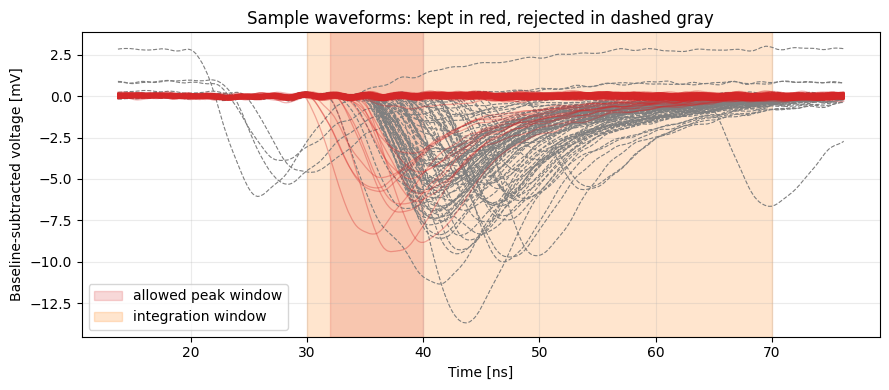

In [40]:
fig, ax = plt.subplots(figsize=(9, 4))
for waveform in voltage_sample_bs_mV[~sample_selection_mask][:500]:
    ax.plot(time_ns, waveform, color="tab:gray", lw=0.8, ls="--")
for waveform in selected_sample_wfs[:500]:
    ax.plot(time_ns, waveform, color="tab:red", alpha=0.35, lw=0.9)
ax.axvspan(*allowed_peak_window_ns, color="tab:red", alpha=0.18, label="allowed peak window")
ax.axvspan(*integration_window_ns, color="tab:orange", alpha=0.20, label="integration window")
ax.set_xlabel("Time [ns]")
ax.set_ylabel("Baseline-subtracted voltage [mV]")
ax.set_title("Sample waveforms: kept in red, rejected in dashed gray")
ax.legend()
fig.tight_layout()

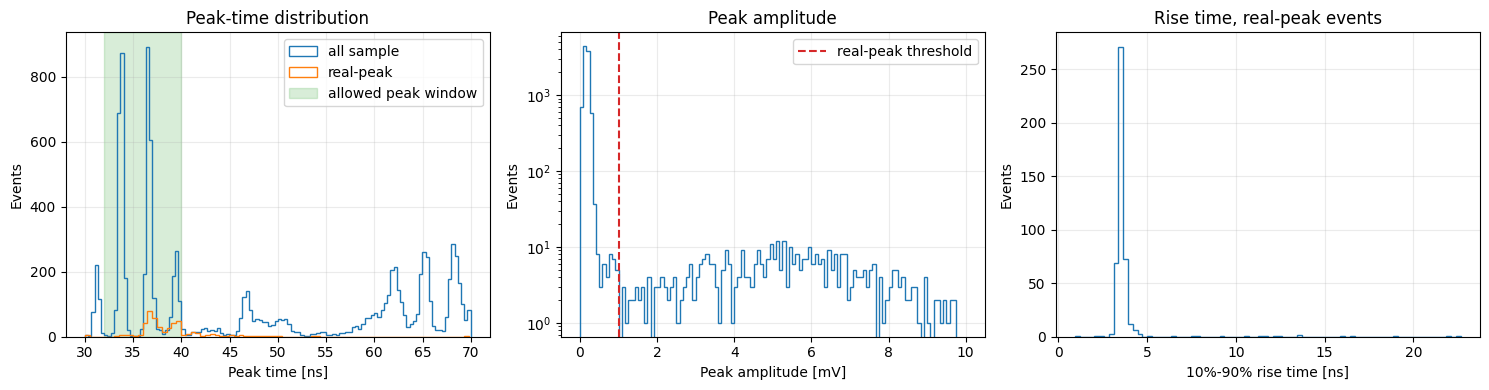

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(sample_timing["peak_time_ns"], bins=120, histtype="step", label="all sample")
axes[0].hist(sample_timing["peak_time_ns"][sample_real_peak_mask], bins=80, histtype="step", label="real-peak")
axes[0].axvspan(*allowed_peak_window_ns, color="tab:green", alpha=0.18, label="allowed peak window")
axes[0].set_xlabel("Peak time [ns]")
axes[0].set_ylabel("Events")
axes[0].set_title("Peak-time distribution")
axes[0].legend()

axes[1].hist(sample_timing["peak_amplitude_mV"], bins=120, range=(0, 10), histtype="step")
axes[1].axvline(abs(out_of_window_peak_voltage_max_mV), color="tab:red", ls="--", label="real-peak threshold")
axes[1].set_xlabel("Peak amplitude [mV]")
axes[1].set_ylabel("Events")
axes[1].set_title("Peak amplitude")
axes[1].set_yscale('log')
axes[1].legend()

axes[2].hist(sample_timing["rise_time_ns"][valid_rise_mask], bins=80, histtype="step")
axes[2].set_xlabel(f"{rise_low_fraction:.0%}-{rise_high_fraction:.0%} rise time [ns]")
axes[2].set_ylabel("Events")
axes[2].set_title("Rise time, real-peak events")
fig.tight_layout()

## Impact of the selection on the mean waveform

Amplitude cut: -2.0 mV -> 436/9999 waveforms kept


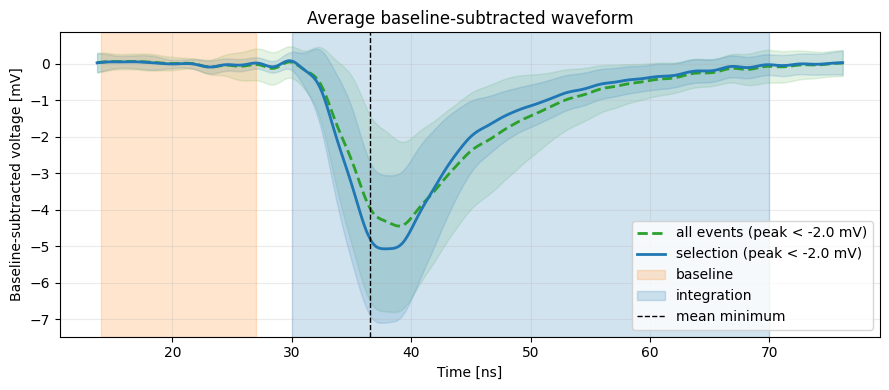

In [42]:
# ------------------------------------------------------------------
# Amplitude cut
# ------------------------------------------------------------------

voltage_threshold_mV = -2.  # set to None to disable
cut_text = (
    f" (peak < {voltage_threshold_mV:.1f} mV)"
    if voltage_threshold_mV is not None
    else ""
)

if voltage_threshold_mV is not None:
    peak_amplitudes = np.min(voltage_sample_bs_mV, axis=1)
    threshold_mask = peak_amplitudes < voltage_threshold_mV

    print(
        f"Amplitude cut: {voltage_threshold_mV:.1f} mV "
        f"-> {threshold_mask.sum()}/{len(threshold_mask)} waveforms kept"
    )

    voltage_sample_bs_mV_thr = voltage_sample_bs_mV[threshold_mask]
    selected_sample_wfs_thr = selected_sample_wfs[
        np.min(selected_sample_wfs, axis=1) < voltage_threshold_mV
    ]
else:
    voltage_sample_bs_mV_thr = voltage_sample_bs_mV
    selected_sample_wfs_thr = selected_sample_wfs


# ------------------------------------------------------------------
# Means and RMS
# ------------------------------------------------------------------

mean_all = np.mean(voltage_sample_bs_mV_thr, axis=0)
std_all = np.std(voltage_sample_bs_mV_thr, axis=0)

mean_selected = np.mean(selected_sample_wfs_thr, axis=0)
std_selected = np.std(selected_sample_wfs_thr, axis=0)


# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 4))

# All events
ax.plot( summary["time_ns"], mean_all, color="tab:green", lw=2, ls="--", label=f"all events{cut_text}")
ax.fill_between( summary["time_ns"], mean_all - std_all, mean_all + std_all, color="tab:green", alpha=0.12)

# Fully selected events
ax.plot( summary["time_ns"], mean_selected, color="tab:blue", lw=2, label=f"selection{cut_text}")
ax.fill_between( summary["time_ns"], mean_selected - std_selected, mean_selected + std_selected, color="tab:blue", alpha=0.15)

ax.axvspan( *baseline_window_ns, color="tab:orange", alpha=0.20, label="baseline")
ax.axvspan( *integration_window_ns, color="tab:blue", alpha=0.20, label="integration")

ax.axvline( summary["time_ns"][idx_min], color="black", ls="--", lw=1, label="mean minimum" )

ax.set_xlabel("Time [ns]")
ax.set_ylabel("Baseline-subtracted voltage [mV]")
ax.set_title("Average baseline-subtracted waveform")
ax.legend(loc="best")
fig.tight_layout()

# Charge

## Best integration window selection

not really used for now

In [43]:
candidate_windows_ns = [
    # (29.0, 65.0),
    # (29.0, 70.0),
    # (29.0, 75.0),
    (30.0, 70.0),
    (30.0, 75.0),
]

charges_by_window = compute_charges_for_windows(
    led1_files,
    baseline_window_ns=baseline_window_ns,
    integration_windows_ns=candidate_windows_ns,
    selection_mask=None,
    chunk_size=4096,
)

print("Original-data candidate fixed-window charges")
print("window [ns]      q0.1%      q1%       q50%      q90%      q99%    q99.9%   [mV ns]")
for window, charge_values in charges_by_window.items():
    q = np.quantile(charge_values, [0.001, 0.01, 0.5, 0.90, 0.99, 0.999])
    print(
        f"{window[0]:4.0f}-{window[1]:<4.0f}"
        f" {q[0]:10.3f} {q[1]:9.3f} {q[2]:9.3f} {q[3]:9.3f} {q[4]:9.3f} {q[5]:9.3f}"
    )

Original-data candidate fixed-window charges
window [ns]      q0.1%      q1%       q50%      q90%      q99%    q99.9%   [mV ns]
  30-70       -6.413    -4.663    -0.050     2.965    78.986   114.457
  30-75       -7.194    -5.199     0.032     3.455    79.362   115.477


In [44]:
charge_all_mV_ns = charges_by_window[integration_window_ns]
charge_mV_ns = charge_all_mV_ns  # short alias for the original, unselected spectrum

print(f"Selected integration window: {integration_window_ns[0]:.1f}-{integration_window_ns[1]:.1f} ns")
print("Original-data charge quantiles [mV ns]:")
for prob, value in zip(
    [0.001, 0.01, 0.10, 0.50, 0.90, 0.99, 0.999],
    np.quantile(charge_all_mV_ns, [0.001, 0.01, 0.10, 0.50, 0.90, 0.99, 0.999]),
):
    print(f"  q{prob:0.3f}: {value:9.4f}")

Selected integration window: 30.0-70.0 ns
Original-data charge quantiles [mV ns]:
  q0.001:   -6.4132
  q0.010:   -4.6629
  q0.100:   -2.6121
  q0.500:   -0.0498
  q0.900:    2.9648
  q0.990:   78.9862
  q0.999:  114.4574


## Compute Charge

In [45]:
selected_charges_by_window = compute_charges_for_windows(
    led1_files,
    baseline_window_ns=baseline_window_ns,
    integration_windows_ns=[integration_window_ns],
    selection_mask=selection["keep_mask"],
    chunk_size=4096,
)
charge_selected_mV_ns = selected_charges_by_window[integration_window_ns]

print(f"Selected events: {selection['n_kept']} / {selection['n_total']} ({selection['efficiency']:.3%})")
print("Selected-data charge quantiles [mV ns]:")
if len(charge_selected_mV_ns):
    for prob, value in zip(
        [0.001, 0.01, 0.10, 0.50, 0.90, 0.99, 0.999],
        np.quantile(charge_selected_mV_ns, [0.001, 0.01, 0.10, 0.50, 0.90, 0.99, 0.999]),
    ):
        print(f"  q{prob:0.3f}: {value:9.4f}")
else:
    print("  no events kept")

Selected events: 125336 / 126728 (98.902%)
Selected-data charge quantiles [mV ns]:
  q0.001:   -6.3521
  q0.010:   -4.6621
  q0.100:   -2.6242
  q0.500:   -0.0786
  q0.900:    2.7969
  q0.990:   74.7945
  q0.999:  110.6523


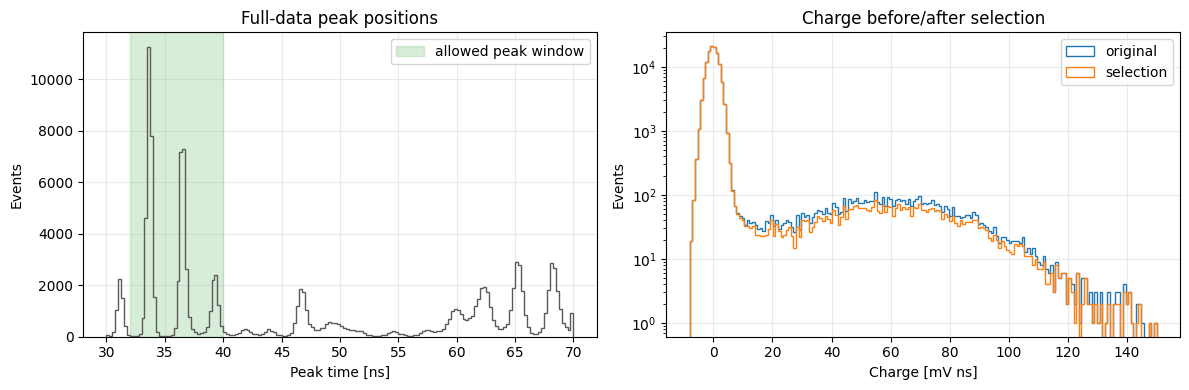

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(selection["peak_time_ns"], bins=160, histtype="step", color="0.35")
axes[0].axvspan(*allowed_peak_window_ns, color="tab:green", alpha=0.18, label="allowed peak window")
axes[0].set_xlabel("Peak time [ns]")
axes[0].set_ylabel("Events")
axes[0].set_title("Full-data peak positions")
axes[0].legend()

axes[1].hist(charge_all_mV_ns, bins=180, range=(-8, 150), histtype="step", label="original")
axes[1].hist(charge_selected_mV_ns, bins=180, range=(-8, 150), histtype="step", label="selection")
axes[1].set_xlabel("Charge [mV ns]")
axes[1].set_ylabel("Events")
axes[1].set_title("Charge before/after selection")
axes[1].set_yscale("log")
axes[1].legend()
fig.tight_layout()

# Fit

In [48]:
def plot_spe_fit_with_residuals(fit, title, max_pe=5, show_errorbars=True, ax=None, ax_resid=None, logscale=True, ylims=None):
    if ax is None or ax_resid is None:
        fig, (ax, ax_resid) = plt.subplots(
            2,
            1,
            figsize=(9, 7),
            sharex=True,
            gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
        )
    else:
        fig = ax.figure

    counts_unc = np.sqrt(np.maximum(fit["counts"], 1))
    residuals = (fit["counts"] - fit["model_counts"]) / counts_unc

    ax.errorbar(
        fit["centers"],
        fit["counts"],
        yerr=counts_unc,
        fmt=".",
        ms=3,
        color="black",
        alpha=0.75,
        label="data",
    )
    ax.plot(fit["centers"], fit["model_counts"], color="tab:red", lw=2.2, label="total fit")

    components = spe_poisson_components(
        fit["centers"],
        fit["parameters"]["n_total"],
        fit["parameters"]["pedestal_mV_ns"],
        fit["parameters"]["sigma_pedestal_mV_ns"],
        fit["parameters"]["spe_area_mV_ns"],
        fit["parameters"]["sigma_spe_mV_ns"],
        fit["parameters"]["mu_led"],
        fit["bin_width"],
        max_pe=max_pe,
    )

    component_colors = ["tab:blue", "tab:orange", "tab:green", "tab:purple", "tab:brown", "tab:cyan"]
    for n_pe, color in zip(components, component_colors):
        ax.plot(fit["centers"], components[n_pe], ls="--", lw=1.5, color=color, label=f"{n_pe} PE")

    ax.set_ylabel("Events / bin")
    ax.set_title(title)
    if logscale: 
        ax.set_yscale("log")
        ax.set_ylim(bottom=0.5)
    if ylims is not None:
        ax.set_ylim(ylims)
    ax.legend(ncol=2, fontsize=8)

    ax_resid.axhline(0, color="black", lw=1)
    ax_resid.axhline(2, color="0.55", lw=0.8, ls=":")
    ax_resid.axhline(-2, color="0.55", lw=0.8, ls=":")
    if show_errorbars:
        ax_resid.errorbar(
            fit["centers"],
            residuals,
            yerr=np.ones_like(residuals),
            fmt=".",
            color="tab:gray",
            ms=3,
            elinewidth=0.8,
            capsize=0,
        )
    else:
        ax_resid.plot(fit["centers"], residuals, ".", color="tab:gray", ms=3)
    ax_resid.set_xlabel("Charge [mV ns]")
    ax_resid.set_ylabel("Residual\n[data-fit]/sigma")
    ax_resid.set_ylim(-8, 8)
    return fig, ax, ax_resid

In [49]:
maxPE = 4
# Optional partial initial guesses. Missing entries are filled by rough spectrum estimates.
spe_fit_p0 = {"spe_area_mV_ns": 55.0}

fit_kwargs = dict(
    fit_range=(-6.0, 150.0),
    bins=250,
    max_pe=maxPE,
    min_spe_area_mV_ns=2.0,
    p0=None#spe_fit_p0,
)

print("ORIGINAL DATA FIT")
fit_all = fit_spe_spectrum(charge_all_mV_ns, **fit_kwargs)
print_spe_fit_result(fit_all)

print("\nSELECTED DATA FIT")
fit_selected = fit_spe_spectrum(charge_selected_mV_ns, **fit_kwargs)
print_spe_fit_result(fit_selected)

# Keep these aliases for quick interactive tweaks below.
fit = fit_all
fits = {"original": fit_all, "selection": fit_selected}

ORIGINAL DATA FIT

Initial fit parameters and bounds:
-------------------------------------------------------------------------------------
Parameter                         Initial          Lower bound          Upper bound
-------------------------------------------------------------------------------------
n_total                            126728                63364               253456
pedestal_mV_ns                  -0.145041                   -6                  150
sigma_pedestal_mV_ns              1.27242               0.0001                  inf
spe_area_mV_ns                          3                    2                  inf
sigma_spe_mV_ns                   1.27242               0.0001                  inf
mu_led                               0.03                0.001                    5
-------------------------------------------------------------------------------------

Fit results:
----------------------------------------------------------------------
Parameter      

/var/folders/80/x5l9nnmd2gb3szz23pnjrgpm0000gn/T/ipykernel_6791/431030242.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


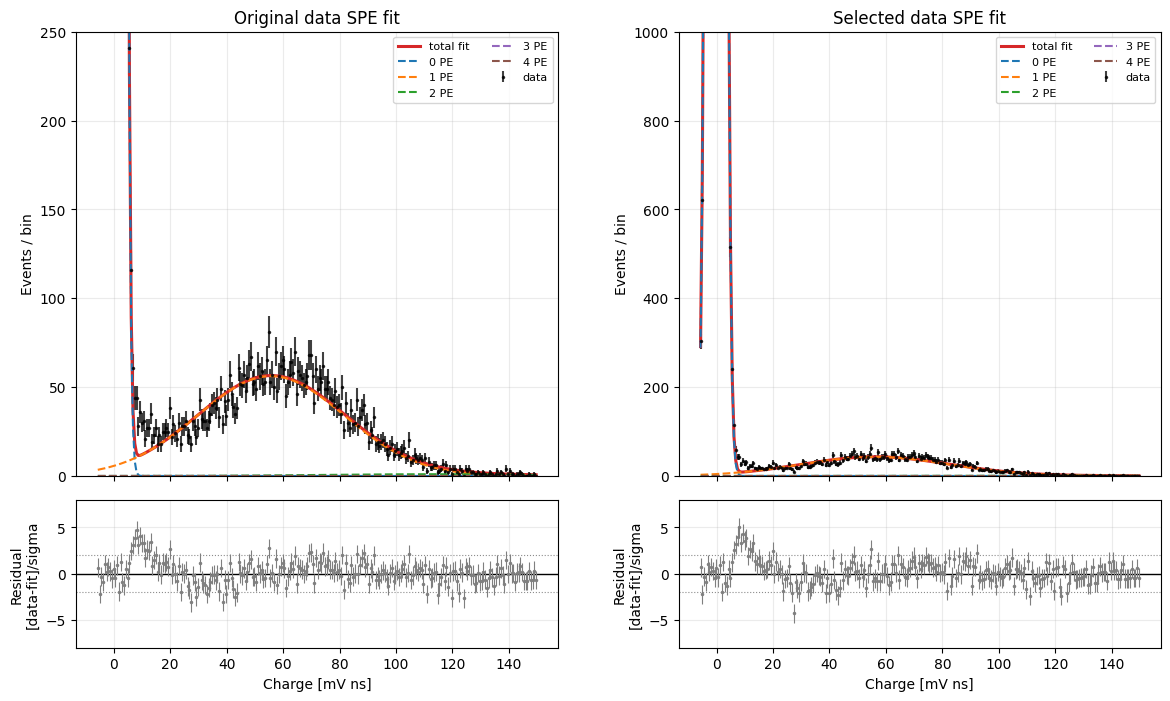

In [50]:
fig, axes = plt.subplots( 2, 2, figsize=(14, 8), sharex="col", gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08, "wspace": 0.25})

plot_spe_fit_with_residuals(
    fit_all,
    "Original data SPE fit",
    max_pe=maxPE,
    show_errorbars=show_residual_errorbars,
    ax=axes[0, 0],
    ax_resid=axes[1, 0],
    logscale=False,
    ylims=(0, 250)
)
plot_spe_fit_with_residuals(
    fit_selected,
    "Selected data SPE fit",
    max_pe=maxPE,
    show_errorbars=show_residual_errorbars,
    ax=axes[0, 1],
    ax_resid=axes[1, 1],
    # logscale=True,
    # ylims=(0, 1e5)
    logscale=False,
    ylims=(0, 1000)
)
fig.show()

In [51]:
print("Fit comparison")
print("quantity                original        selection")
for key in ["pedestal_mV_ns", "sigma_pedestal_mV_ns", "spe_area_mV_ns", "sigma_spe_mV_ns", "mu_led"]:
    print(f"{key:<24} {fit_all['parameters'][key]:10.4g} {fit_selected['parameters'][key]:14.4g}")
print(f"{'chi2/ndof':<24} {fit_all['chi2']/fit_all['ndof']:10.4g} {fit_selected['chi2']/fit_selected['ndof']:14.4g}")

Fit comparison
quantity                original        selection
pedestal_mV_ns              -0.1721        -0.1718
sigma_pedestal_mV_ns          1.957          1.957
spe_area_mV_ns                55.83          56.38
sigma_spe_mV_ns               25.91          26.15
mu_led                      0.04875        0.03761
chi2/ndof                     1.688          1.685


In [52]:
print("Sanity checks")
print(f"1. Baseline residual is centered near zero: {np.mean(summary['baseline_check_mV']):.3e} mV")
print(f"2. Chosen charge window includes the average pulse minimum at {summary['time_ns'][idx_min]:.3f} ns")
print(f"3. Charge units are mV ns by construction: -integral(V_mV dt_ns)")
print(f"4. Original fit chi2/ndof = {fit_all['chi2'] / fit_all['ndof']:.3f}")
print(f"5. Selected fit chi2/ndof = {fit_selected['chi2'] / fit_selected['ndof']:.3f}")

Sanity checks
1. Baseline residual is centered near zero: -3.276e-08 mV
2. Chosen charge window includes the average pulse minimum at 36.573 ns
3. Charge units are mV ns by construction: -integral(V_mV dt_ns)
4. Original fit chi2/ndof = 1.688
5. Selected fit chi2/ndof = 1.685


# Fit draft

ORIGINAL DATA FIT

Initial fit parameters and bounds:
-------------------------------------------------------------------------------------
Parameter                         Initial          Lower bound          Upper bound
-------------------------------------------------------------------------------------
n_total                            126728                63364               253456
pedestal_mV_ns                  -0.145041                   -6                  150
sigma_pedestal_mV_ns              1.27242               0.0001                  inf
spe_area_mV_ns                         10                    2                  inf
sigma_spe_mV_ns                   1.27242               0.0001                  inf
mu_led                               0.03                0.001                    5
-------------------------------------------------------------------------------------
Externally provided initial parameters: spe_area_mV_ns

Fit results:
-------------------------------

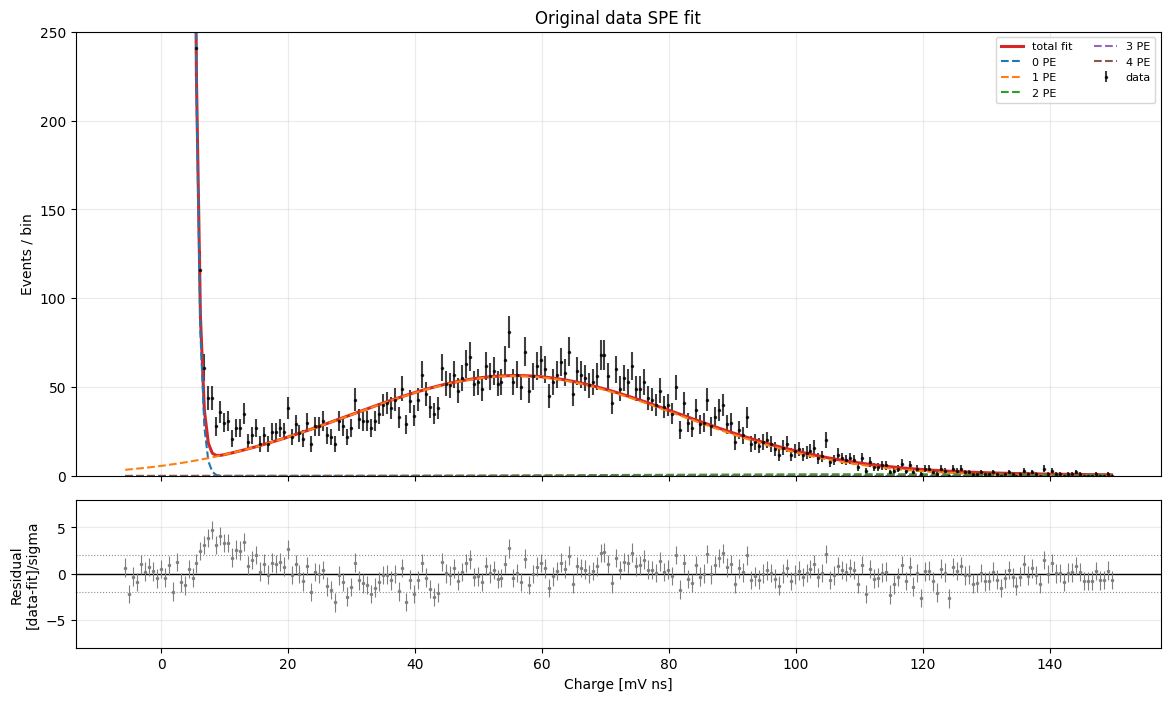

In [32]:
maxPE = 4
# Optional partial initial guesses. Missing entries are filled by rough spectrum estimates.
spe_fit_p0 = {"spe_area_mV_ns": 10.0}

fit_kwargs = dict(
    fit_range=(-6.0, 150.0),
    bins=250,
    max_pe=maxPE,
    min_spe_area_mV_ns=2.0,
    p0=spe_fit_p0,
)

print("ORIGINAL DATA FIT")
fit_all = fit_spe_spectrum(charge_all_mV_ns, **fit_kwargs)
print_spe_fit_result(fit_all)

fig, axes = plt.subplots( 2, 1, figsize=(14, 8), sharex="col", gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08, "wspace": 0.25})

plot_spe_fit_with_residuals(
    fit_all,
    "Original data SPE fit",
    max_pe=maxPE,
    show_errorbars=show_residual_errorbars,
    ax=axes[0],
    ax_resid=axes[1],
    logscale=False,
    ylims=(0, 250)
);